# 1000 Genomes Project

Data preparation

In [6]:
# Automatically reload code in notebook
%load_ext autoreload
%autoreload 2

import pandas as pd
pd.set_option("display.max_columns", None)
import os
os.chdir("/grid/koo/home/schilder/projects/GenomeEncoder/data")

import sys
sys.path.append("code")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import metadata

In [ ]:
from src.onekg import *

In [ ]:
pop = get_pop()
print(pop.shape)
pop.head()

(29, 9)


,Population Description,Population Code,Super Population,DNA from Blood,Offspring available from trios,Pilot Samples,Phase1 Samples,Final Phase Samples,Total
0,"Chinese Dai in Xishuangbanna, China",CDX,EAS,no,yes,0.0,0.0,99.0,99.0
1,"Han Chinese in Bejing, China",CHB,EAS,no,no,91.0,97.0,103.0,106.0
2,"Japanese in Tokyo, Japan",JPT,EAS,no,no,94.0,89.0,104.0,105.0
3,"Kinh in Ho Chi Minh City, Vietnam",KHV,EAS,yes,yes,0.0,0.0,101.0,101.0
4,"Southern Han Chinese, China",CHS,EAS,no,yes,0.0,100.0,108.0,112.0


In [ ]:
ped = get_ped()
print(ped.shape)
ped.head()

(3691, 17)


,Family ID,Individual ID,Paternal ID,Maternal ID,Gender,Phenotype,Population,Relationship,Siblings,Second Order,Third Order,Children,Other Comments,phase 3 genotypes,related genotypes,omni genotypes,affy_genotypes
0,HG00096,HG00096,0,0,1,0,GBR,unrel,0,0,0,0,0,1,0,1,1
1,HG00097,HG00097,0,0,2,0,GBR,unrel,0,0,0,0,0,1,0,1,1
2,HG00098,HG00098,0,0,1,0,GBR,unrel,0,0,0,0,0,0,0,1,1
3,HG00099,HG00099,0,0,2,0,GBR,unrel,0,0,0,0,0,1,0,1,1
4,HG00100,HG00100,0,0,2,0,GBR,unrel,0,0,0,0,0,1,0,1,1


## Download reference genome

In [ ]:
ref_fasta=[("http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa","../data/GRCh38_full_analysis_set_plus_decoy_hla.fa"),
           ("http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa.fai","../data/GRCh38_full_analysis_set_plus_decoy_hla.fa.fai"),
           ("http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.dict","../data/GRCh38_full_analysis_set_plus_decoy_hla.dict")]
download_parallel(ref_fasta)

### Prepare VCFs

In [ ]:
from src.onekg import *

#### Download VCFs

In [ ]:
vcf_files = download_vcfs()

,0,1,2,url,local
0,./ALL.chr1.shapeit2_integrated_snvindels_v2a_2...,1040182789,77f154e53c2b7c36b04d03bab3af8b74,http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data...,/grid/koo/home/schilder/projects/GenomeEncoder...
1,./ALL.chr1.shapeit2_integrated_snvindels_v2a_2...,214641,fddc39a4f2357ad0211d6aace27210ae,http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data...,/grid/koo/home/schilder/projects/GenomeEncoder...
2,./ALL.chr2.shapeit2_integrated_snvindels_v2a_2...,1121169725,f9d29c4935e591b2b269eed7cd7e35d8,http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data...,/grid/koo/home/schilder/projects/GenomeEncoder...
3,./ALL.chr2.shapeit2_integrated_snvindels_v2a_2...,226657,3e9ce6dd07c127373e7839cdf2216e04,http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data...,/grid/koo/home/schilder/projects/GenomeEncoder...
4,./ALL.chr3.shapeit2_integrated_snvindels_v2a_2...,953352016,6e59d00235de71562b4199e09b7e5934,http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data...,/grid/koo/home/schilder/projects/GenomeEncoder...


In [2]:
from src.vcf import * 

#### Reformat VCFs 

In [ ]:
vcf_files_formatted = reformat_vcfs(vcf_dir="1KG/vcf", 
                                    save_dir="1KG/vcf_formatted")


#### Normalise VCFs
Must normalise VCFs to ensure they don't get skipped by bcftools in later steps.

In [ ]:
%%capture

vcf_files_norm = normalize_vcfs(vcf_files=vcf_files_formatted, 
                                save_dir="1KG/vcf_norm")


Skipping chrX
Skipping chr22
Skipping chr21
Skipping chr20
Skipping chr19
Skipping chr18
Skipping chr17
Skipping chr16
Skipping chr15
Skipping chr14
Skipping chr13
Skipping chr12
Skipping chr11
Skipping chr10
Skipping chr9
Skipping chr8
Skipping chr7
Skipping chr6
Skipping chr5
Skipping chr4
Skipping chr3
Normalising chr2
Lines   total/split/realigned/skipped:	6790551/0/0/0
Skipping chr1


## Generate personalized sequences

In [7]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("code")
from src.pyensembl import * 
from src.utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
knownCanonical = get_canonical_transcripts()
print(knownCanonical.TranscriptId.nunique(), len(knownCanonical))

86402 86402


### Generate personalized sequences

In [5]:
import os
os.chdir("/grid/koo/home/schilder/projects/GenomeEncoder/data")

# Load the Reference Genome
vcf_files = list_vcf()

results_all = personalize_seqs(vcf_files, 
                               ref_genome = "GRCh38/GRCh38_full_analysis_set_plus_decoy_hla.fa",
                               save_dir = "1KG/sequence_dict_all",
                               max_files = 1,
                               max_samples = None,
                               max_transcripts = 10,
                               transcript_ids = knownCanonical['TranscriptId'].tolist(),
                               max_workers = 1,
                               # codon_buffer = 'N',
                               to_stop = False,
                               force = False
                               )

 

23 VCF files found.


Processing VCF files:   0%|          | 0/1 [00:00<?, ?it/s]

Processing chr14 transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

Converting all results to dict.


### Compute sequence similarity

#### Nucleotide sequence similarity

In [17]:
nuc_similarity_df = get_sequence_similarity(results_all, seq_type="nuc")
plot_sequence_similarity(nuc_similarity_df, interact=False)

Processing transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

ENST00000013070: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000163416: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000167106: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000202556: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

#### Nucleotide sequence similarity (coding regions only)

Processing transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

ENST00000013070: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000163416: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000167106: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000202556: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

...

ENST00000206451: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000206513: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000206542: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000206595: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000206765: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

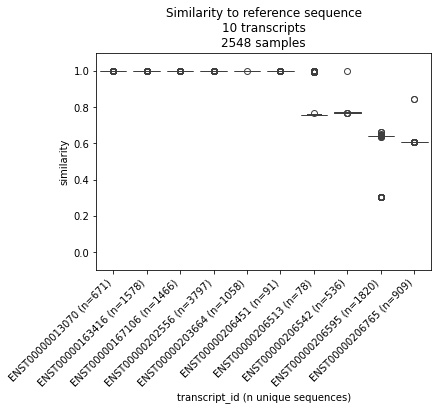

<AxesSubplot:title={'center':'Similarity to reference sequence\n10 transcripts\n2548 samples'}, xlabel='transcript_id (n unique sequences)', ylabel='similarity'>

In [52]:
nuc_subset_similarity_df = get_sequence_similarity(results_all, seq_type="nuc_subset")
plot_sequence_similarity(nuc_subset_similarity_df, interact=False)

#### Amino acid sequence similarity

Processing transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

ENST00000013070: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000163416: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000167106: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000202556: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

...

ENST00000206451: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000206513: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000206542: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000206595: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000206765: Processing samples:   0%|          | 0/2549 [00:00<?, ?it/s]

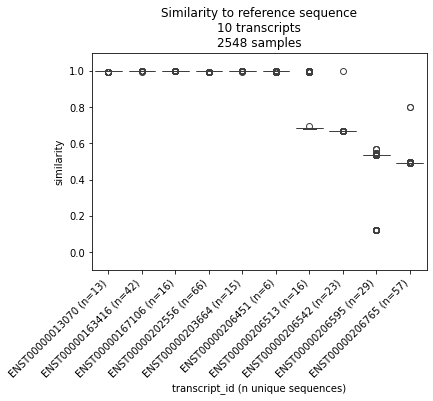

<AxesSubplot:title={'center':'Similarity to reference sequence\n10 transcripts\n2548 samples'}, xlabel='transcript_id (n unique sequences)', ylabel='similarity'>

In [154]:
aa_similarity_df = get_sequence_similarity(results_all, seq_type="aa")
plot_sequence_similarity(aa_similarity_df, interact=False)
# print(aa_similarity_df.groupby('transcript_id')['similarity'].mean().reset_index().rename(columns={'similarity': 'similarity_mean'}))
# print(aa_similarity_df.similarity.describe())

### Plot variant counts per transcript

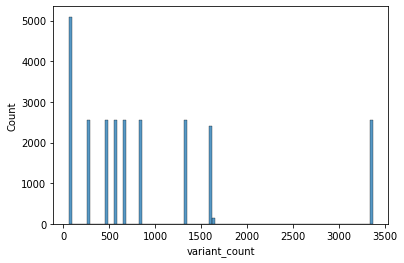

<AxesSubplot:xlabel='variant_count', ylabel='Count'>

In [87]:
variant_counts_df = count_variants(results_all)
plot_variant_counts(variant_counts_df, interact=False)

In [ ]:
# vcf_in = pysam.VariantFile(vcf_files[0])
# chrom = 'chr14'
# db = get_db()
# tx = db.transcript_by_id("ENST00000206765")
# ref_genome = pyfaidx.Fasta("GRCh38/GRCh38_full_analysis_set_plus_decoy_hla.fa")
# ref_seq = ref_genome[chrom][tx.start:tx.end].seq
# ref_seq = ["".join(x) for x in list(ref_seq)]
# nuc_seqs, variant_recorder = personalize_nuc_seqs(tx=tx, vcf_in=vcf_in, ref_genome=ref_genome, ref_seq=ref_seq, sample="HG00273")

# (ref_counts, 
#  seq1_counts, 
#  seq2_counts) = count_variant_lengths(ref_seq, nuc_seqs[0], nuc_seqs[1])
# print(get_sequence_diff_indices(ref_seq, nuc_seqs[0]))
# print(get_sequence_diff_indices(ref_seq, nuc_seqs[1]))


In [ ]:
samples = get_samples(results_all)
seq_df = compare_nuc_seqs(results_all, 
                          transcript_id="ENST00000206765",
                          sample=samples[0],
                          coding_only=True,
                          difference_only=True)

     chrom  position  exon_index ref_seq seq1 seq2
236     14  24262269           0       T    T    A
877     14  24259704           4       G    G    C
1092    14  24259182           5       G   GT   GT
1910    14  24255236          10       G   GC   GC
2220    14  24254283          12       C   CG   CG
ref_seq length: 14063
seq1 length: 14063
seq2 length: 14063
Sequence similarity: nuc_seq
seq1: 0.9981511768470455
seq2: 0.9982222854298514
Sequence similarity: subset nuc_seq
seq1: 0.6062831497348021
seq2: 0.6062831497348021
Sequence similarity: subset prot_seq
seq1: 0.4920440636474908
seq2: 0.4920440636474908


### ESM2

In [93]:
# Automatically reload code in notebook
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("code")
from src.ESM import * 
from src.utils import *
from src.pyensembl import *

import os
os.chdir("/grid/koo/home/schilder/projects/GenomeEncoder/data")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import esm
import torch

In [5]:
# set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [6]:
# Load the ESM2 Model
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()  # Set model to evaluation mode
print()

In [8]:
# if "aa_similarity_df" not in globals():
#     aa_similarity_df = get_sequence_similarity(results_all, seq_type="aa")
# min_proteoforms = 2
# transcript_ids = aa_similarity_df.loc[aa_similarity_df['unique_sequences'] >= min_proteoforms].transcript_id.unique()


In [11]:
(seq_to_proteoform, 
 transcript_to_proteoform, 
 sample_to_proteoform, 
 proteoform_to_stopcodons, 
 samples, 
 batches) = get_torch_data(save_dir = "1KG/sequence_dict_all",
                           alphabet=alphabet,
                        #    transcript_ids=transcript_ids
                           )

Loading data from 1KG/sequence_dict_all


Processing transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

ENST00000163416: Processing samples.:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000167106: Processing samples.:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000203664: Processing samples.:   0%|          | 0/2549 [00:00<?, ?it/s]

...

ENST00000206765: Processing samples.:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000206595: Processing samples.:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000206451: Processing samples.:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000202556: Processing samples.:   0%|          | 0/2549 [00:00<?, ?it/s]

ENST00000206542: Processing samples.:   0%|          | 0/2549 [00:00<?, ?it/s]

In [14]:
print(f"{len(set(seq_to_proteoform.values()))} unique proteoforms across {len(set(transcript_to_proteoform.keys()))} transcripts in {len(set(samples))} sample(s).")

138 unique proteoforms across 10 transcripts in 2549 sample(s).


In [12]:
(esm_results, 
 save_paths, 
 failed_transcripts) = get_embeddings(
     batches, 
     model=model, 
     alphabet=alphabet, 
     save_dir="1KG/embeddings/esm2_t33_650M_UR50D",
     force=False
     )

Embedding transcript proteoforms:   0%|          | 0/10 [00:00<?, ?it/s]

In [13]:
seq_reps = get_representations(batches=batches, 
                               save_paths=save_paths)

Found 10 ESM2 files


Extracting sequence representations:   0%|          | 0/10 [00:00<?, ?it/s]

In [14]:
(transcript_variances, 
 transcript_variance_means) = get_representation_variances(seq_reps)

Computing transcript variances:   0%|          | 0/10 [00:00<?, ?it/s]

### Embed transcript variants

In [19]:
X = get_representation_matrix(seq_reps, 
                              save_path = f"1KG/embeddings/esm2_t33_650M_UR50D/sequence_representation_matrix.pt",)

Restructuring sequence representations into 2D array
torch.Size([138, 1280])


In [20]:
reducer, embedding, nan_indices = run_umap(X)

Filtering matrix
Matrix shape before filtering: torch.Size([138, 1280])
Matrix shape after filtering: torch.Size([138, 1280])
Running UMAP
UMAP( verbose=True)
Fri Dec 27 23:24:31 2024 Construct fuzzy simplicial set
Fri Dec 27 23:24:32 2024 Finding Nearest Neighbors
Fri Dec 27 23:24:34 2024 Finished Nearest Neighbor Search
Fri Dec 27 23:24:49 2024 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Dec 27 23:24:51 2024 Finished embedding


In [56]:
embedding_df = get_umap_df(seq_reps, embedding, nan_indices)
plot_umap(embedding_df,
          interact=True,
          marginal_x="histogram", marginal_y="histogram",
        #   facet_col="transcript_id",
            opacity=0.5,
            
        #   bw_adjust=0.5, # Decrease bandwidth for higher granularity 
        #   levels=20, # Increase number of contour levels
        #   thresh=0.05 # Lower threshold to show more detail
          )

In [ ]:
## Patient representations

In [15]:
# Construct patient representations as a 3D tensor (samples x transcripts x ESM2 representations)
patient_tensor = get_patient_tensor(seq_reps,
                                    sample_to_proteoform)
print(patient_tensor['tensor'].shape)


Populating patient tensor:   0%|          | 0/50980 [00:00<?, ?it/s]

torch.Size([2549, 10, 2, 1280])


In [75]:
factors, transcript_contributions = run_tensor_factorization(patient_tensor['tensor'],
                                    n_components={'samples':10,
                                                    'transcripts':10,
                                                    'phases':10,
                                                    'features':10},
                                    n_epochs=500,
                                    learning_rate=0.01)


Epochs completed:   0%|          | 0/500 [00:00<?, ?it/s]

In [127]:
tx_contrib_df, l2_contrib_df = get_transcript_contributions(factors, patient_tensor, l2_norm=True)
# tx_contributions_df.head()

# # identify transcript with highest variance in contribution
# top_tx = tx_contributions_df.std(axis=0).sort_values(ascending=False).head(5)
# # identify transcript with highest mean contribution
# top_tx = tx_contributions_df.mean(axis=0).sort_values(ascending=False).head(5)
# top_tx

l2_contrib_df



,contribution
ENST00000013070,1.000000
ENST00000206595,0.975677
ENST00000206451,0.454875
ENST00000202556,0.373419
ENST00000206542,0.312580
ENST00000167106,0.279335
ENST00000163416,0.266216
ENST00000206513,0.191891
ENST00000203664,0.100488
ENST00000206765,0.023293


In [19]:
# Reduce sample factors with UMAP
reducer, embedding, nan_indices = run_umap(factors['samples'])


Filtering matrix
Matrix shape before filtering: torch.Size([2549, 10])
Matrix shape after filtering: torch.Size([2549, 10])
Running UMAP
UMAP( verbose=True)
Sat Dec 28 01:34:16 2024 Construct fuzzy simplicial set
Sat Dec 28 01:34:20 2024 Finding Nearest Neighbors
Sat Dec 28 01:34:22 2024 Finished Nearest Neighbor Search
Sat Dec 28 01:34:24 2024 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sat Dec 28 01:34:27 2024 Finished embedding


In [128]:
import src.onekg as onekg
sample_metadata = onekg.get_sample_metadata()
embedding_df = pd.DataFrame(embedding, 
                            index=patient_tensor['samples'],
                            columns=[f"UMAP_{i+1}" for i in range(embedding.shape[1])]
                            ).merge(sample_metadata, left_index=True, right_index=True
                                    ).merge(tx_contrib_df, left_index=True, right_index=True)
embedding_df.head()


,UMAP_1,UMAP_2,Family ID,Individual ID,Paternal ID,Maternal ID,Gender,Phenotype,Population,Relationship,...,ENST00000202556,ENST00000203664,ENST00000206765,ENST00000167106,ENST00000206513,ENST00000206595,ENST00000163416,ENST00000013070,ENST00000206451,ENST00000206542
HG01101,6.332128,7.469221,PR19,HG01101,0,0,1,0,PUR,father,...,0.169911,0.723977,0.533238,0.572088,0.893400,-0.899325,-0.224908,0.254405,0.187501,-0.971702
HG01868,6.644119,4.350872,VN035,HG01868,0,0,2,0,KHV,unrel,...,4.786542,0.249910,-0.020840,7.055020,-7.243995,-43.507900,-5.349037,39.405609,15.578536,-3.910485
HG03971,3.690511,3.293918,IT048,HG03971,0,0,1,0,ITU,father,...,5.832328,1.352107,1.244566,4.630943,-2.350754,-20.758726,-4.336159,26.038055,14.459804,-9.451435
NA19092,7.006454,4.453389,Y040,NA19092,0,0,1,0,YRI,father,...,0.103907,0.182906,0.352870,0.859762,0.180712,-0.106233,-0.857210,-0.042278,-0.072354,1.537410
HG01605,5.170214,7.942839,IBS023,HG01605,0,0,2,0,IBS,mother,...,-0.101668,-0.612936,-0.547617,-1.476696,0.198419,0.284183,2.242657,-0.136056,-0.166695,-3.017771


In [129]:
for col in l2_contrib_df.index.tolist()[:3]:
    fig = px.scatter(embedding_df, x='UMAP_1', y='UMAP_2', 
                    color=col)
    fig.show()

In [130]:
import plotly.express as px
for col in ['Population', 'Super Population', 'DNA from Blood']:
    fig = px.scatter(embedding_df, x='UMAP_1', y='UMAP_2', 
                    color=col)
    fig.show()

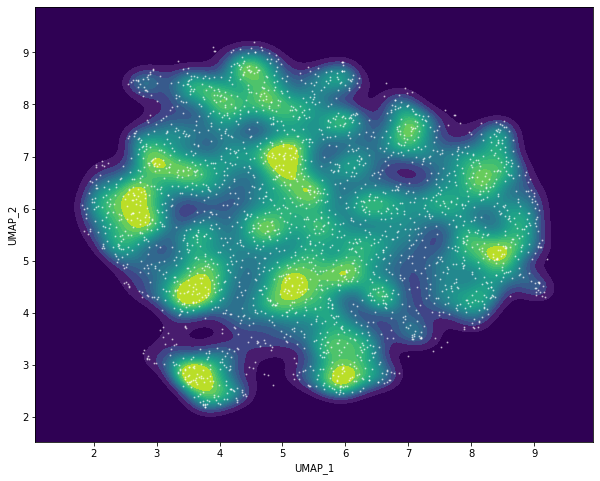

In [50]:
plot_density(embedding_df,
            bw_adjust=0.5, # Decrease bandwidth for higher granularity 
          levels=20, # Increase number of contour levels
          thresh=0.05, # Lower threshold to show more detail
          figsize=(10, 8)
          )

[IUPAC codes](https://www.bioinformatics.org/sms/iupac.html)
| IUPAC nucleotide code | Base |
|----------------------|------|
| A | Adenine |
| C | Cytosine |
| G | Guanine |
| T (or U) | Thymine (or Uracil) |
| R | A or G |
| Y | C or T |
| S | G or C |
| W | A or T |
| K | G or T |
| M | A or C |
| B | C or G or T |
| D | A or G or T |
| H | A or C or T |
| V | A or C or G |
| N | any base |
| . or - | gap |
